# Week 6 — Motor Imagery to Aido Humanoid Bridge

This notebook transfers the CSP + LDA motor-imagery classification pipeline
from EEG data to synthetic Aido Humanoid joint-sensor data.

The formal analogy is:

- EEG electrodes → Aido joint sensors
- EEG spatial activation patterns → joint kinematic patterns
- Motor imagery classes → robot motion primitives
- CSP spatial filtering → CSP-style filtering of joint-sensor channels
- LDA classification → robot motor-state classification

Three Aido motion primitives are simulated:

1. WALK
2. REACH
3. BALANCE

Each trial contains six simulated joint-angle sensor channels with
class-specific kinematic patterns and added noise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from mne.decoding import CSP

In [2]:
SEED = 42
rng = np.random.default_rng(SEED)

print("Random seed:", SEED)

Random seed: 42


In [ ]:
## define the synthetic dataset
N_TRIALS_PER_CLASS = 100
N_CHANNELS = 6
N_TIMES = 200
SAMPLING_RATE = 100

CLASSES = ["WALK", "REACH", "BALANCE"]

t = np.arange(N_TIMES) / SAMPLING_RATE

print("Trial duration:", t[-1], "seconds")

Trial duration: 1.99 seconds


In [4]:
SENSOR_NAMES = [
    "Left Shoulder",
    "Right Shoulder",
    "Left Elbow",
    "Right Elbow",
    "Left Hip",
    "Right Hip"
]

In [ ]:
## Generate one WALK trial
def generate_walk_trial(rng):
    trial = np.zeros((N_CHANNELS, N_TIMES))

    freq = rng.normal(1.2, 0.08)
    phase = rng.uniform(0, 2 * np.pi)

    # Small upper-body movement
    trial[0] = 3 * np.sin(2 * np.pi * freq * t + phase)
    trial[1] = 3 * np.sin(2 * np.pi * freq * t + phase + np.pi)

    trial[2] = 2 * np.sin(2 * np.pi * freq * t + phase)
    trial[3] = 2 * np.sin(2 * np.pi * freq * t + phase + np.pi)

    # Strong alternating hip movement
    trial[4] = 15 * np.sin(2 * np.pi * freq * t + phase)
    trial[5] = 15 * np.sin(2 * np.pi * freq * t + phase + np.pi)

    # Sensor noise
    trial += rng.normal(0, 1.5, trial.shape)

    return trial

In [6]:
def generate_reach_trial(rng):
    trial = np.zeros((N_CHANNELS, N_TIMES))

    freq = rng.normal(0.6, 0.05)
    phase = rng.uniform(0, 2 * np.pi)

    # Strong upper-body motion
    trial[0] = 12 * np.sin(2 * np.pi * freq * t + phase)
    trial[1] = 10 * np.sin(2 * np.pi * freq * t + phase)

    trial[2] = 15 * np.sin(2 * np.pi * freq * t + phase)
    trial[3] = 13 * np.sin(2 * np.pi * freq * t + phase)

    # Relatively stable lower body
    trial[4] = 2 * np.sin(2 * np.pi * freq * t)
    trial[5] = 2 * np.sin(2 * np.pi * freq * t)

    trial += rng.normal(0, 1.5, trial.shape)

    return trial

In [7]:
def generate_balance_trial(rng):
    trial = np.zeros((N_CHANNELS, N_TIMES))

    freq = rng.normal(0.25, 0.03)
    phase = rng.uniform(0, 2 * np.pi)

    trial[0] = 2.0 * np.sin(2 * np.pi * freq * t + phase)
    trial[1] = 2.0 * np.sin(2 * np.pi * freq * t + phase)

    trial[2] = 1.5 * np.sin(2 * np.pi * freq * t + phase)
    trial[3] = 1.5 * np.sin(2 * np.pi * freq * t + phase)

    # Small postural corrections
    trial[4] = 4.0 * np.sin(2 * np.pi * freq * t + phase)
    trial[5] = 4.0 * np.sin(2 * np.pi * freq * t + phase)

    trial += rng.normal(0, 1.5, trial.shape)

    return trial

In [8]:
X = []
y = []

generators = {
    0: generate_walk_trial,
    1: generate_reach_trial,
    2: generate_balance_trial
}

for label, generator in generators.items():
    for _ in range(N_TRIALS_PER_CLASS):
        trial = generator(rng)

        X.append(trial)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (300, 6, 200)
y shape: (300,)


In [9]:
unique, counts = np.unique(y, return_counts=True)

for label, count in zip(unique, counts):
    print(CLASSES[label], count)

WALK 100
REACH 100
BALANCE 100


In [17]:
## Visualize the synthetic data before CSP
class_means = {}

for label, class_name in enumerate(CLASSES):
    class_means[class_name] = X[y == label].mean(axis=0)

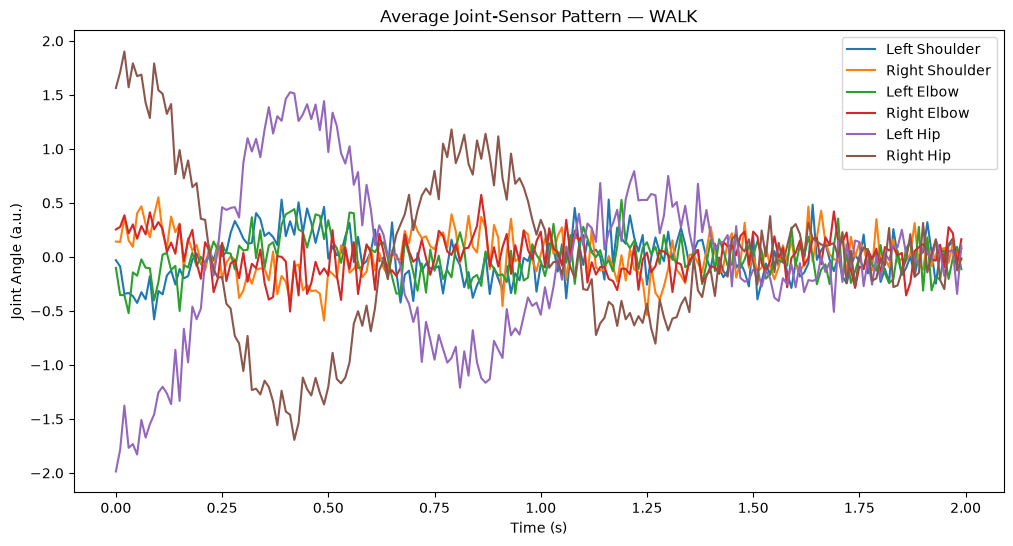

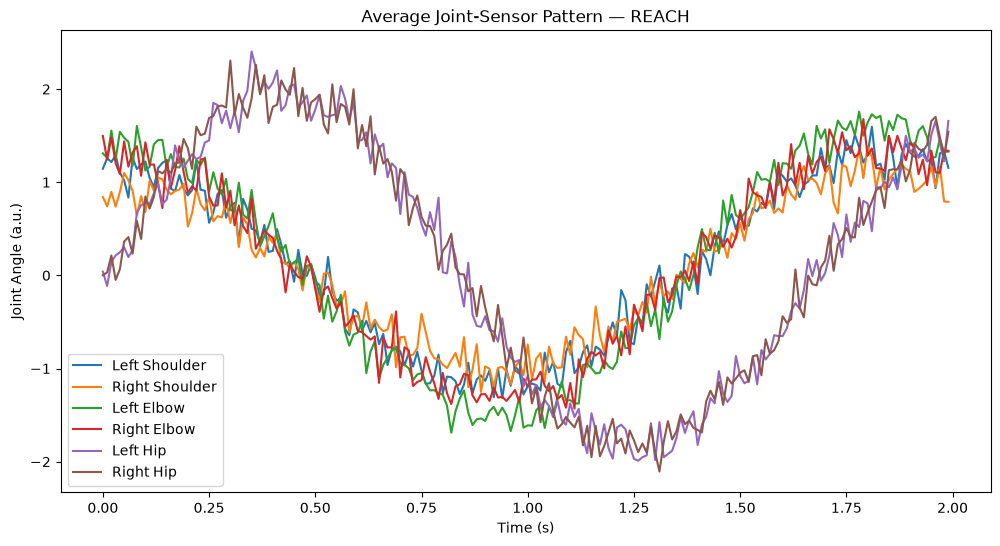

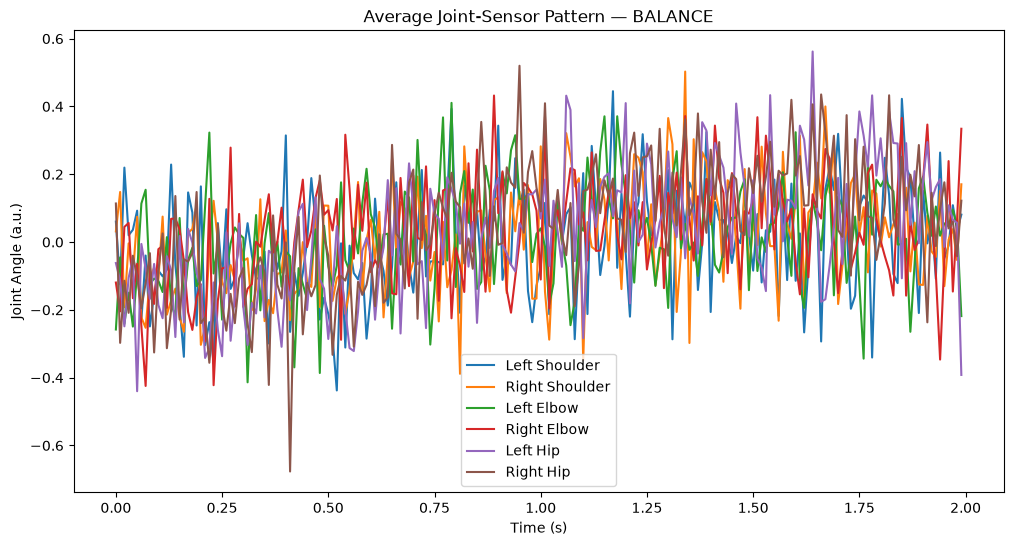

In [18]:
for class_name in CLASSES:

    fig, ax = plt.subplots(figsize=(12, 6))

    for ch in range(N_CHANNELS):
        ax.plot(
            t,
            class_means[class_name][ch],
            label=SENSOR_NAMES[ch]
        )

    ax.set_title(f"Average Joint-Sensor Pattern — {class_name}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Joint Angle (a.u.)")
    ax.legend()

    plt.show()

In [16]:
## train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)


Training: (225, 6, 200)
Testing: (75, 6, 200)


## CSP Feature Extraction

The Week 3 CSP pipeline was designed for binary classification. Since the
Aido dataset contains three motion primitives (WALK, REACH, and BALANCE),
we extend the same CSP method using a one-vs-rest strategy.

For each motion class, CSP filters are learned to maximize the variance
difference between that class and the remaining two classes:

- WALK vs. REST
- REACH vs. REST
- BALANCE vs. REST

The resulting CSP features are concatenated and later used as input to LDA.

In [19]:
def normalized_covariance(X):
    """
    X: shape (n_channels, n_time_samples)
    Returns normalized channel covariance matrix.
    """
    X = X - X.mean(axis=1, keepdims=True)

    C = X @ X.T
    tr = np.trace(C)

    if tr <= 0:
        raise ValueError("Encountered a trial with zero covariance trace.")

    return C / tr


def mean_class_covariance(X_class):
    covs = np.asarray([
        normalized_covariance(X)
        for X in X_class
    ])

    return covs.mean(axis=0)

In [20]:
def fit_csp(R1, R2, n_pairs=2, eps=1e-10):
    """
    Solve R1 w = lambda R2 w.

    Parameters
    ----------
    R1 : covariance matrix for target class
    R2 : covariance matrix for rest classes
    n_pairs : number of filters selected from each eigenvalue extreme

    Returns
    -------
    W : CSP spatial filters
    selected_eigenvalues : eigenvalues of selected filters
    all_eigenvalues : all sorted generalized eigenvalues
    """

    n_channels = R1.shape[0]
    n_pairs = min(n_pairs, n_channels // 2)

    # Regularization for numerical stability
    R2_reg = R2 + eps * np.eye(n_channels)

    # Generalized eigenvalue problem
    M = np.linalg.pinv(R2_reg) @ R1

    eigvals, eigvecs = np.linalg.eig(M)

    eigvals = np.real(eigvals)
    eigvecs = np.real(eigvecs)

    # Sort eigenvalues from largest to smallest
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Select filters from both extremes
    select = (
        list(range(n_pairs))
        + list(range(n_channels - n_pairs, n_channels))
    )

    W = eigvecs[:, select].T

    # Normalize filters
    W = W / np.linalg.norm(W, axis=1, keepdims=True)

    return W, eigvals[select], eigvals

In [21]:
## fit one-vs-rest CSP for each class
N_PAIRS = 2

csp_filters = {}
csp_eigenvalues = {}

for label, class_name in enumerate(CLASSES):

    # Target class
    X_target = X_train[y_train == label]

    # All other classes
    X_rest = X_train[y_train != label]

    # Mean covariance matrices
    R_target = mean_class_covariance(X_target)
    R_rest = mean_class_covariance(X_rest)

    # Fit CSP
    W, selected_eigvals, all_eigvals = fit_csp(
        R_target,
        R_rest,
        n_pairs=N_PAIRS
    )

    csp_filters[class_name] = W
    csp_eigenvalues[class_name] = selected_eigvals

    print(f"{class_name} vs REST")
    print("  Target trials:", X_target.shape[0])
    print("  Rest trials:", X_rest.shape[0])
    print("  W shape:", W.shape)
    print("  Selected eigenvalues:", selected_eigvals)
    print()

WALK vs REST
  Target trials: 75
  Rest trials: 150
  W shape: (4, 6)
  Selected eigenvalues: [1.95991193e+01 1.88692724e-01 4.60552029e-02 1.49453486e-02]

REACH vs REST
  Target trials: 75
  Rest trials: 150
  W shape: (4, 6)
  Selected eigenvalues: [1.48669594e+01 1.49068753e-01 7.81660750e-02 1.28986642e-02]

BALANCE vs REST
  Target trials: 75
  Rest trials: 150
  W shape: (4, 6)
  Selected eigenvalues: [32.01436273 11.91832525  0.24342707  0.18828954]



In [22]:
## log-variance feature function
def csp_logvar_features(X_trials, W, eps=1e-12):
    """
    Transform trials into CSP log-variance features.

    X_trials:
        (n_trials, n_channels, n_time_samples)

    W:
        (n_components, n_channels)
    """

    feature_rows = []

    for X_trial in X_trials:

        # Apply spatial filters
        Z = W @ X_trial

        # Variance of each CSP component
        variances = np.var(Z, axis=1, ddof=1)

        # Relative variance
        relative_var = variances / (variances.sum() + eps)

        # Log transform
        logvar = np.log(relative_var + eps)

        feature_rows.append(logvar)

    return np.asarray(feature_rows)

In [26]:
## multiclass CSP feature matrix
def multiclass_csp_features(X_trials, csp_filters):
    """
    Apply each one-vs-rest CSP filter bank and concatenate
    the resulting log-variance features.
    """

    feature_blocks = []

    for class_name in CLASSES:

        W = csp_filters[class_name]

        features = csp_logvar_features(
            X_trials,
            W
        )

        feature_blocks.append(features)

    return np.concatenate(feature_blocks, axis=1)

In [27]:
X_train_csp = multiclass_csp_features(
    X_train,
    csp_filters
)

X_test_csp = multiclass_csp_features(
    X_test,
    csp_filters
)

print("Training CSP features:", X_train_csp.shape)
print("Testing CSP features:", X_test_csp.shape)

Training CSP features: (225, 12)
Testing CSP features: (75, 12)


## LDA Classification and Evaluation

The concatenated one-vs-rest CSP log-variance features are used as input
to a Linear Discriminant Analysis (LDA) classifier.

LDA learns linear decision boundaries that separate the three Aido motion
primitives: WALK, REACH, and BALANCE.

Performance is evaluated on the held-out test set using:

- Classification accuracy
- Macro F1 score
- Confusion matrix
- CSP feature-space visualization

In [28]:
## train LDA
lda = LinearDiscriminantAnalysis()

lda.fit(X_train_csp, y_train)

y_pred = lda.predict(X_test_csp)

In [29]:
accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Test Accuracy: {accuracy:.3f}")
print(f"Macro F1 Score: {f1:.3f}")

Test Accuracy: 1.000
Macro F1 Score: 1.000


In [31]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASSES,
        digits=3
    )
)

              precision    recall  f1-score   support

        WALK      1.000     1.000     1.000        25
       REACH      1.000     1.000     1.000        25
     BALANCE      1.000     1.000     1.000        25

    accuracy                          1.000        75
   macro avg      1.000     1.000     1.000        75
weighted avg      1.000     1.000     1.000        75



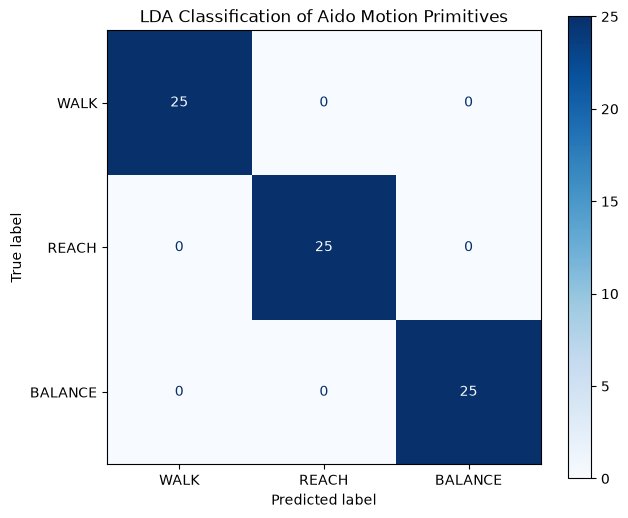

In [32]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASSES
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title("LDA Classification of Aido Motion Primitives")

plt.show()

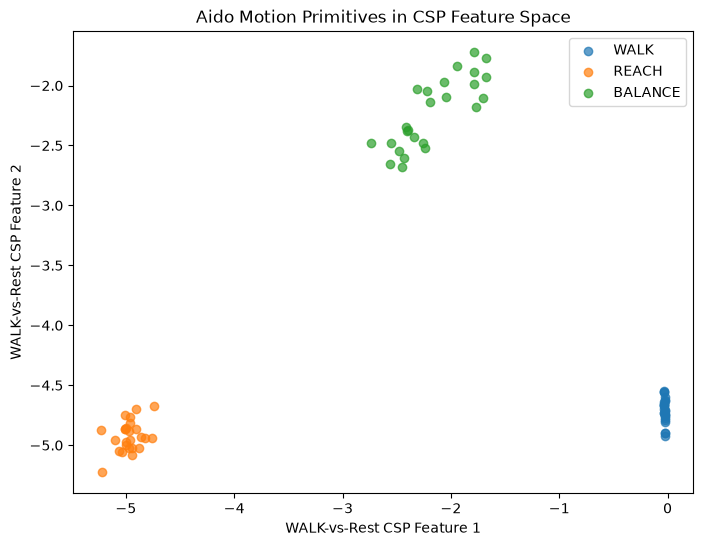

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))

for label, class_name in enumerate(CLASSES):

    mask = y_test == label

    ax.scatter(
        X_test_csp[mask, 0],
        X_test_csp[mask, 1],
        alpha=0.7,
        label=class_name
    )

ax.set_xlabel("WALK-vs-Rest CSP Feature 1")
ax.set_ylabel("WALK-vs-Rest CSP Feature 2")
ax.set_title("Aido Motion Primitives in CSP Feature Space")
ax.legend()

plt.show()

In [34]:
## Use LDA to project CSP features into 2D
lda_vis = LinearDiscriminantAnalysis(
    n_components=2
)

X_train_lda_2d = lda_vis.fit_transform(
    X_train_csp,
    y_train
)

X_test_lda_2d = lda_vis.transform(
    X_test_csp
)

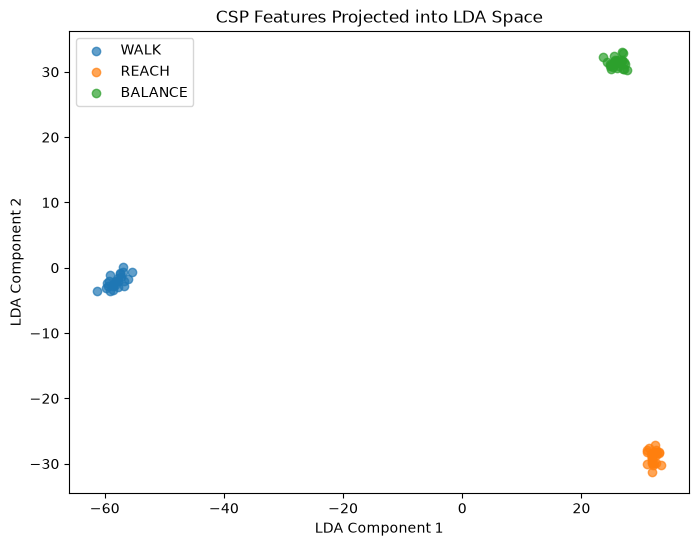

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))

for label, class_name in enumerate(CLASSES):

    mask = y_test == label

    ax.scatter(
        X_test_lda_2d[mask, 0],
        X_test_lda_2d[mask, 1],
        alpha=0.7,
        label=class_name
    )

ax.set_xlabel("LDA Component 1")
ax.set_ylabel("LDA Component 2")
ax.set_title("CSP Features Projected into LDA Space")
ax.legend()

plt.show()

In [36]:
results = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Macro F1 Score"
    ],
    "Score": [
        accuracy,
        f1
    ]
})

results

,Metric,Score
0,Test Accuracy,1.0
1,Macro F1 Score,1.0


### Interpretation of Classification Performance

The CSP + LDA pipeline achieved a test accuracy and macro F1 score of 1.000.
This high performance is expected for the current synthetic dataset because
the three motion primitives were intentionally generated with distinct
spatial covariance patterns.

WALK is dominated by alternating hip activity, REACH by upper-body
shoulder and elbow activity, and BALANCE by lower-amplitude coordinated
postural motion. These differences are directly captured by CSP's
variance-based spatial filtering.

Therefore, the perfect classification result should be interpreted as
evidence that the CSP + LDA pipeline can recover the designed kinematic
structure of the synthetic dataset, rather than as an estimate of
performance on real humanoid sensor data.

## Comparison with EEG Motor Imagery Benchmark

The synthetic Aido Humanoid experiment was designed as a formal analogue
of the EEG motor imagery classification task. In the EEG pipeline, CSP
extracts spatial variance patterns across scalp electrodes and LDA uses
these features to classify imagined motor states. In the Aido pipeline,
the same principle is applied to spatial patterns across joint sensors to
classify robot motion primitives.

The Aido CSP + LDA pipeline achieved:

- **Test accuracy:** 1.000
- **Macro F1 score:** 1.000

The EEG motor imagery benchmark uses real BCI Competition IV Dataset 2a
recordings, with 22 EEG channels sampled at 250 Hz. Unlike the synthetic
Aido dataset, EEG signals contain biological variability, measurement
noise, artifacts, and substantial overlap between motor-imagery classes.

The perfect performance on the synthetic Aido dataset should therefore
not be interpreted as evidence that robot motion-state classification is
inherently easier than EEG motor imagery classification. Instead, the
synthetic WALK, REACH, and BALANCE trials were intentionally generated
with distinct spatial covariance structures. CSP successfully recovered
these designed differences.

Overall, the analogy holds at the signal-processing level: both problems
represent motor states as class-dependent spatial patterns across multiple
sensor channels, and CSP transforms these patterns into discriminative
variance-based features that can be classified using LDA.

In [39]:
comparison = pd.DataFrame({
    "Property": [
        "Sensor channels",
        "Motor classes",
        "Data source",
        "Spatial feature method",
        "Classifier",
        "Accuracy",
        "Macro F1"
    ],
    "EEG Motor Imagery": [
        "22 scalp EEG channels",
        "Left / Right / Foot / Tongue",
        "Real BCI Competition IV 2a recordings",
        "CSP",
        "LDA",
        "Run EEG notebook to obtain",
        "Run EEG notebook to obtain"
    ],
    "Aido Humanoid": [
        "6 joint-angle sensors",
        "WALK / REACH / BALANCE",
        "Synthetic kinematic data",
        "One-vs-rest CSP",
        "LDA",
        "1.000",
        "1.000"
    ]
})

comparison

,Property,EEG Motor Imagery,Aido Humanoid
0,Sensor channels,22 scalp EEG channels,6 joint-angle sensors
1,Motor classes,Left / Right / Foot / Tongue,WALK / REACH / BALANCE
2,Data source,Real BCI Competition IV 2a recordings,Synthetic kinematic data
3,Spatial feature method,CSP,One-vs-rest CSP
4,Classifier,LDA,LDA
5,Accuracy,Run EEG notebook to obtain,1.000
6,Macro F1,Run EEG notebook to obtain,1.000
